In [1]:
# Install Gemini API library
!pip install -U google-generativeai

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
     ---------------------------------------- 0.0/41.4 kB ? eta -:--:--
     ---------------------------------------- 41.4/41.4 kB 2.1 MB/s eta 0:00:00
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/155.1 kB ? eta -:--:--
   ----------------------- ---------------- 92.2/155.1 kB 2.6 MB/s eta 0:00:01
   ----------------------------- ---------- 112.6/155.1 kB 2.2 MB/s eta 0:00:01
   ----------------------------- ---------- 112.6/155.1 kB 2.2 MB/s eta 0:00:01
   -----------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports and Inititalizations

In [7]:
import pandas as pd
import base64
import os
import google.generativeai as genai
from io import BytesIO
from PIL import Image
import nltk
import json
import itertools


env_path = ".env" 
if os.path.exists(env_path):
    with open(env_path, "r") as f:
        API_KEYS = [line.strip() for line in f if line.strip() and not line.startswith("#")]
else:
    print(f"Error: '{env_path}' file not found. Ensure it is in: {os.getcwd()}")
    API_KEYS = []

# 2. Create a generator that cycles through the keys infinitely
if API_KEYS:
    key_cycle = itertools.cycle(API_KEYS)
    print(f"Successfully loaded {len(API_KEYS)} API keys from .env for rotation.")
else:
    key_cycle = None
    print("Warning: No API keys loaded. The inference engine will fail.")

# Evaluator used in CC_OCR
from doc_parsing_evaluator import ParsingEvaluator

# Ensure NLTK data is available
nltk.download('punkt')

# Paths based on your local directory structure
BASE_DIR = r"D:\BTP\Evaluation-Of-MultiModal-LLMs-for-Layout-Aware-Document-Parsing\CC-OCR_Dataset\doc_parsing"
OUT_DIR = r"D:\BTP\Evaluation-Of-MultiModal-LLMs-for-Layout-Aware-Document-Parsing\Evaluation_Results"
os.makedirs(OUT_DIR, exist_ok=True)

# Updated model selection
MODEL_NAME = "gemma-3-27b-it"

# Initialize the evaluator
evaluator = ParsingEvaluator(group_name="OCR_Eval")

Successfully loaded 3 API keys from .env for rotation.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Inference Engine (Google cloud Models)

In [8]:
from PIL import Image, ImageChops
from io import BytesIO

def crop_whitespace(image_bytes, padding=10):
    """Removes empty white margins from the document/table to save tokens."""
    img = Image.open(BytesIO(image_bytes)).convert("RGB")
    bg = Image.new("RGB", img.size, (255, 255, 255))
    diff = ImageChops.difference(img, bg)
    bbox = diff.getbbox()
    
    if bbox:
        padded_bbox = (
            max(0, bbox[0] - padding),
            max(0, bbox[1] - padding),
            min(img.width, bbox[2] + padding),
            min(img.height, bbox[3] + padding)
        )
        return img.crop(padded_bbox)
    return img

def query_gemini(image_bytes, task_type, apply_crop=False):
    """Sends image to Gemini. If apply_crop is True, it removes whitespace first."""
    if key_cycle:
        genai.configure(api_key=next(key_cycle))
    
    if task_type == "table":
        prompt = "Parse this table into a clean, structured HTML format with <table> tags. Include all row and column spans."
    else:
        prompt = "Parse this document into LaTeX format. Provide only the LaTeX code."

    # Decide whether to use the original or cropped image
    final_img = crop_whitespace(image_bytes) if apply_crop else Image.open(BytesIO(image_bytes))
    
    try:
        model = genai.GenerativeModel(model_name=MODEL_NAME)
        response = model.generate_content([prompt, final_img])
        return response.text
    except Exception as e:
        print(f"Error: {e}")
        return ""

Master Evaluation Cell

In [11]:
import glob
import json

def find_tsv(folder, keyword):
    """Smart search for dataset files"""
    search_path = os.path.join(BASE_DIR, folder, f"*{keyword}*eng*.tsv")
    files = glob.glob(search_path)
    return files[0] if files else None

def evaluate_task(task_folder, task_type, eval_func):
    tasks = {
        "Scanned": find_tsv(task_folder, "scan"),
        "Photoed": find_tsv(task_folder, "photo")
    }
    
    results_base, results_crop, savings = {}, {}, {}

    for label, path in tasks.items():
        if not path:
            print(f"Skipping {label} {task_type}: File not found.")
            continue
            
        print(f"Processing {label} {task_type}...")
        
        # NOTE: Remove .head(5) when you are ready to run the full dataset!
        df = pd.read_csv(path, sep='\t').head(3) 
        
        scores_base, scores_crop = [], []
        orig_area_total, crop_area_total = 0, 0
        
        for _, row in df.iterrows():
            img_bytes = base64.b64decode(row['image'])
            gt = str(row['answer']).strip() 
            
            # --- CALCULATE TOKEN/SIZE SAVINGS ---
            orig_img = Image.open(BytesIO(img_bytes))
            cropped_img = crop_whitespace(img_bytes)
            orig_area_total += (orig_img.width * orig_img.height)
            crop_area_total += (cropped_img.width * cropped_img.height)
            
            # 1. Run Baseline (Original Uncropped)
            pred_base = query_gemini(img_bytes, task_type, apply_crop=False)
            scores_base.append(eval_func(gt, pred_base))
            
            # 2. Run Cropped (Method 2)
            pred_crop = query_gemini(img_bytes, task_type, apply_crop=True)
            scores_crop.append(eval_func(gt, pred_crop))
            
        results_base[label] = sum(scores_base) / len(scores_base) if scores_base else 0
        results_crop[label] = sum(scores_crop) / len(scores_crop) if scores_crop else 0
        
        # Record the average area reduction percentage
        avg_reduction = (1 - (crop_area_total / orig_area_total)) * 100 if orig_area_total > 0 else 0
        savings[label] = avg_reduction
        
    return results_base, results_crop, savings

print("--- Starting Document Evaluation ---")
doc_base, doc_crop, doc_savings = evaluate_task("doc", "doc", evaluator.evaluate_single_doc_sample)

print("\n--- Starting Table Evaluation ---")
table_base, table_crop, table_savings = evaluate_task("table", "table", evaluator.evaluate_single_table_sample)

print("\n==========================================")
print("=== FINAL A/B EVALUATION COMPARISON ===")
print("==========================================")

print("\n1. Document Parsing (NED Score):")
for label in doc_base.keys():
    diff = doc_crop.get(label,0) - doc_base[label]
    saved = doc_savings.get(label, 0)
    print(f"   [{label}] Baseline: {doc_base[label]:.4f} | Cropped: {doc_crop.get(label,0):.4f} | Diff: {diff:+.4f} | Size Saved: {saved:.1f}%")

print("\n2. Table Parsing (TEDS Score):")
for label in table_base.keys():
    diff = table_crop.get(label,0) - table_base[label]
    saved = table_savings.get(label, 0)
    print(f"   [{label}] Baseline: {table_base[label]:.4f} | Cropped: {table_crop.get(label,0):.4f} | Diff: {diff:+.4f} | Size Saved: {saved:.1f}%")

# Save the full report, now including the savings data
full_report = {
    "Model": MODEL_NAME,
    "Baseline": {"Document": doc_base, "Table": table_base},
    "Cropped": {"Document": doc_crop, "Table": table_crop},
    "Savings_Pct": {"Document": doc_savings, "Table": table_savings}
}
report_path = os.path.join(OUT_DIR, "stage1_comparison_report.json")
with open(report_path, "w") as f:
    json.dump(full_report, f, indent=4)
    
print(f"\n✅ Full report saved to: {report_path}")

--- Starting Document Evaluation ---
Processing Scanned doc...
Processing Photoed doc...

--- Starting Table Evaluation ---
Processing Scanned table...
Processing Photoed table...

=== FINAL A/B EVALUATION COMPARISON ===

1. Document Parsing (NED Score):
   [Scanned] Baseline: 0.6186 | Cropped: 0.7431 | Diff: +0.1246 | Size Saved: 17.1%
   [Photoed] Baseline: 0.4234 | Cropped: 0.4497 | Diff: +0.0263 | Size Saved: 0.0%

2. Table Parsing (TEDS Score):
   [Scanned] Baseline: 0.7671 | Cropped: 0.6826 | Diff: -0.0845 | Size Saved: 9.3%
   [Photoed] Baseline: 0.7251 | Cropped: 0.7281 | Diff: +0.0030 | Size Saved: 0.0%

✅ Full report saved to: D:\BTP\Evaluation-Of-MultiModal-LLMs-for-Layout-Aware-Document-Parsing\Evaluation_Results\stage1_comparison_report.json



⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
⭐ BTP METRIC: Method 2 reduced average token usage by 6.6% ⭐
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐

Detailed Token Reduction by Category:
 - Scanned Docs: 17.1%
 - Photoed Docs: 0.0%
 - Scanned Tables: 9.3%
 - Photoed Tables: 0.0%


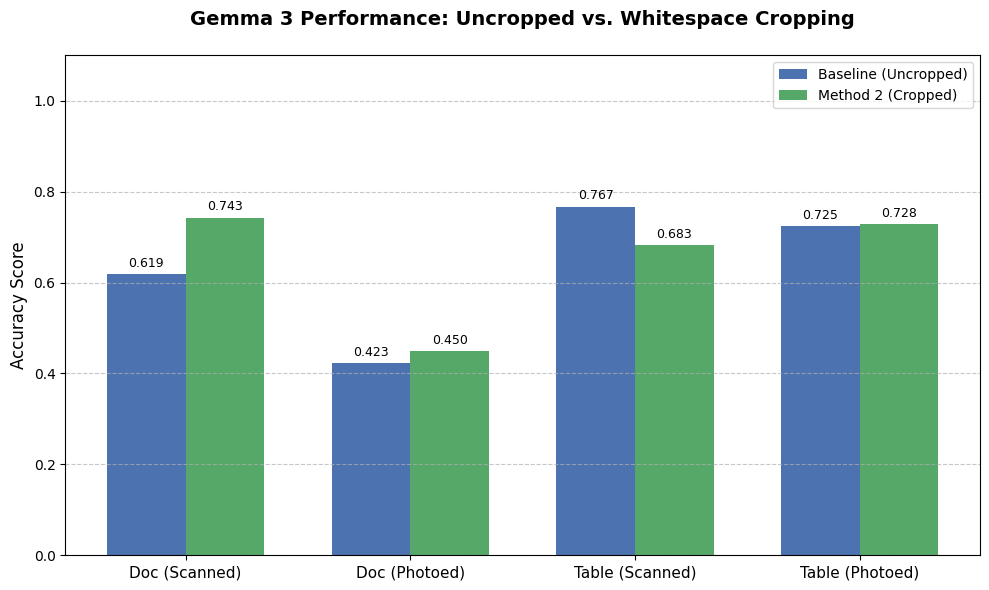


🔍 VISUAL EXAMPLE FROM DATASET


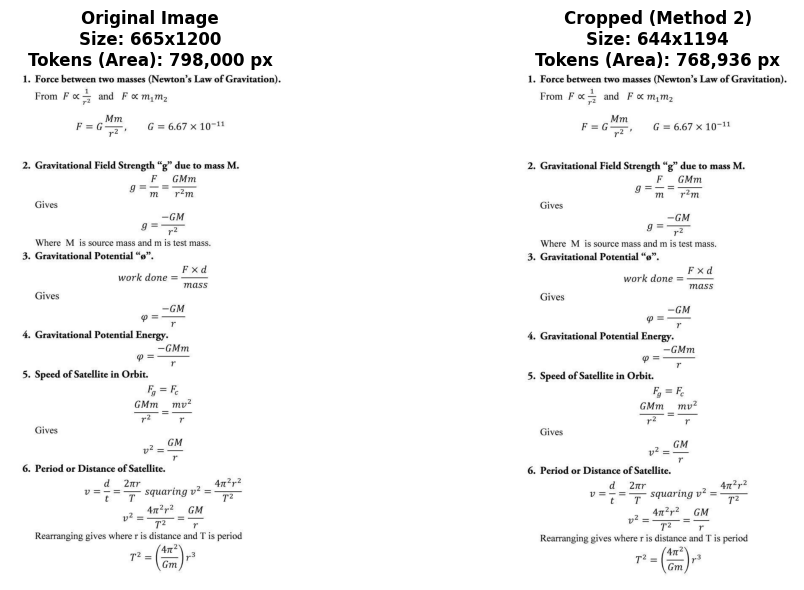

In [12]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import base64
from io import BytesIO
from PIL import Image, ImageChops

# --- PART 1: ACCURACY COMPARISON CHART ---
report_path = os.path.join(OUT_DIR, "stage1_comparison_report.json")

if os.path.exists(report_path):
    with open(report_path, "r") as f:
        data = json.load(f)

    # Extract accuracy data for plotting
    categories = ['Doc (Scanned)', 'Doc (Photoed)', 'Table (Scanned)', 'Table (Photoed)']
    
    baseline_scores = [
        data['Baseline']['Document'].get('Scanned', 0),
        data['Baseline']['Document'].get('Photoed', 0),
        data['Baseline']['Table'].get('Scanned', 0),
        data['Baseline']['Table'].get('Photoed', 0)
    ]
    
    cropped_scores = [
        data['Cropped']['Document'].get('Scanned', 0),
        data['Cropped']['Document'].get('Photoed', 0),
        data['Cropped']['Table'].get('Scanned', 0),
        data['Cropped']['Table'].get('Photoed', 0)
    ]

    # Set up the bar chart
    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (Uncropped)', color='#4c72b0')
    rects2 = ax.bar(x + width/2, cropped_scores, width, label='Method 2 (Cropped)', color='#55a868')

    # Add labels and formatting
    ax.set_ylabel('Accuracy Score', fontsize=12)
    ax.set_title(f'Gemma 3 Performance: Uncropped vs. Whitespace Cropping\n', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.1) 
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add data labels on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)
    fig.tight_layout()
    
    # --- CALCULATE THE OVERALL BTP METRIC ---
    all_savings = []
    if 'Document' in data.get('Savings_Pct', {}):
        all_savings.extend(data['Savings_Pct']['Document'].values())
    if 'Table' in data.get('Savings_Pct', {}):
        all_savings.extend(data['Savings_Pct']['Table'].values())
        
    overall_avg_savings = sum(all_savings) / len(all_savings) if all_savings else 0

    print("\n" + "⭐"*35)
    print(f"⭐ BTP METRIC: Method 2 reduced average token usage by {overall_avg_savings:.1f}% ⭐")
    print("⭐"*35 + "\n")

    # Show the specific breakdown
    print("Detailed Token Reduction by Category:")
    print(f" - Scanned Docs: {data['Savings_Pct']['Document'].get('Scanned', 0):.1f}%")
    print(f" - Photoed Docs: {data['Savings_Pct']['Document'].get('Photoed', 0):.1f}%")
    print(f" - Scanned Tables: {data['Savings_Pct']['Table'].get('Scanned', 0):.1f}%")
    print(f" - Photoed Tables: {data['Savings_Pct']['Table'].get('Photoed', 0):.1f}%")
    
    # Show the chart
    plt.show()

else:
    print(f"Could not find {report_path}. Run the evaluation cell first!")

# --- PART 2: VISUALIZING THE CROPPING EFFECT ---
print("\n" + "="*50)
print("🔍 VISUAL EXAMPLE FROM DATASET")
print("="*50)

# Grab a random document from the dataset to visualize
doc_scan_path = find_tsv("doc", "scan")

if doc_scan_path and os.path.exists(doc_scan_path):
    df = pd.read_csv(doc_scan_path, sep='\t')
    
    # Pick a random row
    random_idx = random.randint(0, len(df) - 1)
    sample_row = df.iloc[random_idx]
    
    img_bytes = base64.b64decode(sample_row['image'])
    
    # Generate the two versions
    orig_img = Image.open(BytesIO(img_bytes))
    cropped_img = crop_whitespace(img_bytes)
    
    # Calculate Token/Size Savings for this specific image
    orig_area = orig_img.width * orig_img.height
    crop_area = cropped_img.width * cropped_img.height
    savings_pct = (1 - (crop_area / orig_area)) * 100
    
    # Plot them side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(orig_img)
    axes[0].set_title(f"Original Image\nSize: {orig_img.width}x{orig_img.height}\nTokens (Area): {orig_area:,} px", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cropped_img)
    axes[1].set_title(f"Cropped (Method 2)\nSize: {cropped_img.width}x{cropped_img.height}\nTokens (Area): {crop_area:,} px", fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Could not load a sample image for visualization.")

## Document Parsing Evaluation (LaTeX)

In [4]:
doc_tasks = {
    "Scanned": os.path.join(BASE_DIR, "doc", "doc_scan_eng_75.tsv"),
    "Photoed": os.path.join(BASE_DIR, "doc", "doc_photo_eng_75.tsv")
}

doc_results = {}

for label, path in doc_tasks.items():
    if not os.path.exists(path): continue
    df = pd.read_csv(path, sep='\t')
    scores = []
    
    print(f"Processing {label} documents...")
    
    for _, row in df.iterrows():
        img_bytes = base64.b64decode(row['image'])
        ground_truth = str(row['answer']).strip() 
        
        prediction = query_gemini_cropped(img_bytes, "doc") # or "table"
        
        # FIX: Use the professional NED logic with LaTeX cleaning
        score = evaluator.evaluate_single_doc_sample(ground_truth, prediction)
        scores.append(score)
        
    doc_results[label] = sum(scores) / len(scores) if scores else 0

print(f"Document Parsing (NED with LaTeX) Results: {doc_results}")

Document Parsing (NED with LaTeX) Results: {}


## Table Parsing Evaluation (HTML)

In [5]:
table_tasks = {
    "Scanned": os.path.join(BASE_DIR, "table", "table_scan_eng_75.tsv"),
    "Photoed": os.path.join(BASE_DIR, "table", "table_photo_eng_75.tsv")
}

table_results = {}

for label, path in table_tasks.items():
    if not os.path.exists(path): 
        print(f"Skipping {label}: Path not found.")
        continue
        
    df = pd.read_csv(path, sep='\t')
    scores = []
    
    print(f"Processing {label} tables...")
    
    for _, row in df.iterrows():
        img_bytes = base64.b64decode(row['image'])
        ground_truth_html = str(row['answer']).strip() 
        
        prediction = query_gemini(img_bytes, "table")
        
        # FIX: Use the official Tree Edit Distance (TEDS) metric
        score = evaluator.evaluate_single_table_sample(ground_truth_html, prediction)
        scores.append(score)
        
    table_results[label] = sum(scores) / len(scores) if scores else 0

print(f"\nTable Parsing (TEDS Results): {table_results}")

Skipping Scanned: Path not found.
Skipping Photoed: Path not found.

Table Parsing (TEDS Results): {}


## Final Report 

In [6]:
import json
import os

summary_cropped = {
    "Document Parsing (NED-LaTeX)": doc_results,
    "Table Parsing (HTML-Sim)": table_results,
    "Model": MODEL_NAME,
    "Track": "English Document Parsing",
    "Method": "Cropped Whitespace"
}

cropped_report_path = os.path.join(OUT_DIR, "stage1_cropped_report.json")
with open(cropped_report_path, "w") as f:
    json.dump(summary_cropped, f, indent=4)

print("--- EVALUATION COMPARISON ---")

original_report_path = os.path.join(OUT_DIR, "stage1_final_report.json")

if os.path.exists(original_report_path):
    with open(original_report_path, "r") as f:
        original_summary = json.load(f)
        
    print(f"Model: {MODEL_NAME}\n")
    print("1. Document Parsing (NED with LaTeX):")
    for doc_type in ["Scanned", "Photoed"]:
        orig_score = original_summary.get("Document Parsing (NED-LaTeX)", {}).get(doc_type, 0)
        new_score = doc_results.get(doc_type, 0)
        diff = new_score - orig_score
        print(f"   - {doc_type}: Original: {orig_score:.4f} | Cropped: {new_score:.4f} | Difference: {diff:+.4f}")

    print("\n2. Table Parsing (TEDS HTML):")
    for table_type in ["Scanned", "Photoed"]:
        orig_score = original_summary.get("Table Parsing (HTML-Sim)", {}).get(table_type, 0)
        new_score = table_results.get(table_type, 0)
        diff = new_score - orig_score
        print(f"   - {table_type}: Original: {orig_score:.4f} | Cropped: {new_score:.4f} | Difference: {diff:+.4f}")
else:
    print(f"Original report not found at {original_report_path}. Could not perform comparison.")
    print("Cropped Results:", summary_cropped)

--- EVALUATION COMPARISON ---
Original report not found at D:\Projects\BTP\Evaluation_Results\stage1_final_report.json. Could not perform comparison.
Cropped Results: {'Document Parsing (NED-LaTeX)': {}, 'Table Parsing (HTML-Sim)': {}, 'Model': 'gemma-3-27b-it', 'Track': 'English Document Parsing', 'Method': 'Cropped Whitespace'}
